In [2]:
# 1) Imports and configuration
import os
import time
import random
import operator
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Dataset and split
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 100
train_frac = 0.8  # keeps n_test_traj=20 when samples_to_load=100

# Reproducibility
seed = 32

# Preprocessing / chunking
sub = 1
chunk_len = 16  # same role as T in train_RNO.ipynb
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True

# Optimization
batch_size = 75
epochs = 25
learning_rate = 1e-3
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5

# RNO model
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

# Rollout eval
rollout_h = 5  # must be >= 5
sample_id = 0
start_chunk = 0


In [3]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")

device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [4]:
# 3) Data loading (state only)
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
).float()  # (ntraj, nt, nx)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples")
print(f"solutions (raw): {tuple(solutions.shape)}")
print(f"x_cord: {tuple(x_cord.shape)}")
print(f"dt: {dt}")


Loaded 100/3000 samples
solutions (raw): (100, 401, 100)
x_cord: (100, 1)
dt: 0.001


In [5]:
# 4) Helper functions
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nx) -> (ntraj, n_chunks, chunk_size, nx)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)


def build_state_windows(sol_chunks, n_intervals_inner):
    # sol_chunks: (ntraj, n_chunks, chunk_len, nx, 1)
    x_list, y_list = [], []
    for traj in sol_chunks:
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_list.append(traj[i : i + n_intervals_inner])
            y_list.append(traj[i + n_intervals_inner])

    x = torch.stack(x_list, dim=0).float()  # (N, n_intervals, chunk_len, nx, 1)
    y = torch.stack(y_list, dim=0).float()  # (N, chunk_len, nx, 1)
    return x, y


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


In [6]:
# 5) State-only preprocessing: crop, split, chunk
# Spatial subsample on state/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

ntraj, nt_raw, nx = solutions.shape

# Time crop to multiple of chunk_len
nt_usable = round_down(nt_raw, chunk_len)
solutions = solutions[:, :nt_usable, :]

# Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(
        int(tipping_data_split_prop * solutions.shape[1]), chunk_len
    )
    solutions = solutions[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
n_chunks = nt // chunk_len

# Train/test split by trajectory
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]

# Chunk and append channel dim
sol_train_chunks = chunk_time_axis(sol_train, chunk_len).unsqueeze(
    -1
)  # (n_train_traj, n_chunks, chunk_len, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test_traj, n_chunks, chunk_len, nx, 1)

print("After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"ntraj={ntraj}, nt={nt}, nx={nx}, n_chunks={n_chunks}")
print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
print(f"sol_train_chunks.shape: {tuple(sol_train_chunks.shape)}")
print(f"sol_test_chunks.shape: {tuple(sol_test_chunks.shape)}")


After preprocessing:
solutions: (100, 400, 100)
ntraj=100, nt=400, nx=100, n_chunks=25
n_train_traj=80, n_test_traj=20
sol_train_chunks.shape: (80, 25, 16, 100, 1)
sol_test_chunks.shape: (20, 25, 16, 100, 1)


In [7]:
# 6) Build state-only train/test windows and dataloaders
x_train, y_train = build_state_windows(sol_train_chunks, n_intervals)
x_test, y_test = build_state_windows(sol_test_chunks, n_intervals)

train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

print(f"x_train: {tuple(x_train.shape)}")
print(f"y_train: {tuple(y_train.shape)}")
print(f"x_test: {tuple(x_test.shape)}")
print(f"y_test: {tuple(y_test.shape)}")

xb, yb = next(iter(train_loader))
print(f"train batch x: {tuple(xb.shape)}")
print(f"train batch y: {tuple(yb.shape)}")

x_in = xb.permute(0, 1, 4, 2, 3)
print(f"x_in passed to RNO: {tuple(x_in.shape)} (channel dim must be 1)")


x_train: (1520, 5, 16, 100, 1)
y_train: (1520, 16, 100, 1)
x_test: (380, 5, 16, 100, 1)
y_test: (380, 16, 100, 1)
train batch x: (75, 5, 16, 100, 1)
train batch y: (75, 16, 100, 1)
x_in passed to RNO: (75, 5, 1, 16, 100) (channel dim must be 1)


In [8]:
# 7) RNO model, optimizer, scheduler, loss
from neuralop.models import RNO

in_channels = int(x_train.shape[-1])
out_channels = int(y_train.shape[-1])

print(f"Model config -> in_channels={in_channels}, out_channels={out_channels}")
assert in_channels == 1, f"Expected in_channels=1, got {in_channels}"
assert out_channels == 1, f"Expected out_channels=1, got {out_channels}"

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=1,
    out_channels=1,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

print("RNO in_channels/out_channels:", model.in_channels, model.out_channels)
print("Model parameters:", count_params(model))

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


Model config -> in_channels=1, out_channels=1
RNO in_channels/out_channels: 1 1
Model parameters: 3138141


### What Training loop Optimizes
- Cell #8 optimizes only one-step next-chunk prediction (`num_steps=1`) during training.
- The loss is computed between the predicted next chunk and the immediate ground-truth next chunk.
- It does not directly optimize full-trajectory or long-horizon rollout error.
- Multi-step rollout quality is therefore an out-of-distribution consequence of repeated one-step usage.
- To explicitly optimize trajectory-level error, a separate multi-step fine-tuning phase is needed.
- Both endpoint MSE and endpoint relative L2 are reported below per horizon. (MSE is scale-dependent, while relative L2 is scale-normalized by target magnitude.)




In [10]:
# 8) Training loop (state-only)
import torch.nn.functional as F

num_train_samples = x_train.shape[0]
num_test_samples = x_test.shape[0]
training_loss_history = []
test_loss_history = []
result_dir = f"result_rno_state_only_{seed}"
os.makedirs(result_dir, exist_ok=True)
log_file = os.path.join(result_dir, "log.csv")
with open(log_file, "w") as f:
    f.write("epoch,loss_train_mse,loss_test_l2,runtime\n")
print("Begin RNO training (state-only):")
for ep in range(1, epochs + 1):
    t_start = time.time()
    model.train()
    train_mse = 0.0
    for x_batch, y_batch in tqdm(train_loader, leave=False):
        x_batch = x_batch.to(device).float()  # (B, n_intervals, chunk_len, nx, 1)
        y_batch = y_batch.to(device).float()  # (B, chunk_len, nx, 1)
        x_in = x_batch.permute(0, 1, 4, 2, 3)  # (B, n_intervals, 1, chunk_len, nx)
        out = model.predict(x_in, num_steps=1)[:, -1]  # (B, 1, chunk_len, nx)
        out = out.permute(0, 2, 3, 1)  # (B, chunk_len, nx, 1)
        loss = F.mse_loss(out, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_mse += loss.item() * x_batch.size(0)
    model.eval()
    test_l2_metric = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()
            x_in = x_batch.permute(0, 1, 4, 2, 3)
            out = model.predict(x_in, num_steps=1)[:, -1]
            out = out.permute(0, 2, 3, 1)
            test_l2_metric += lploss(out, y_batch).item() * x_batch.size(0)
    train_mse /= num_train_samples
    test_l2_metric /= num_test_samples
    training_loss_history.append(train_mse)
    test_loss_history.append(test_l2_metric)
    runtime = time.time() - t_start
    print(
        f"Epoch {ep:03d}/{epochs} | train_mse={train_mse:.4e} | test_l2={test_l2_metric:.4e} | runtime={runtime:.2f}s"
    )
    with open(log_file, "a") as f:
        f.write(f"{ep},{train_mse},{test_l2_metric},{runtime}\n")


Begin RNO training (state-only):


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 001/25 | train_mse=2.0386e+00 | test_l2=7.4068e+01 | runtime=5.76s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 002/25 | train_mse=2.0186e+00 | test_l2=7.3640e+01 | runtime=5.05s


...

Epoch 023/25 | train_mse=4.5701e-01 | test_l2=5.8667e+01 | runtime=5.05s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 024/25 | train_mse=4.5671e-01 | test_l2=5.8641e+01 | runtime=4.99s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 025/25 | train_mse=4.5381e-01 | test_l2=5.8615e+01 | runtime=5.00s


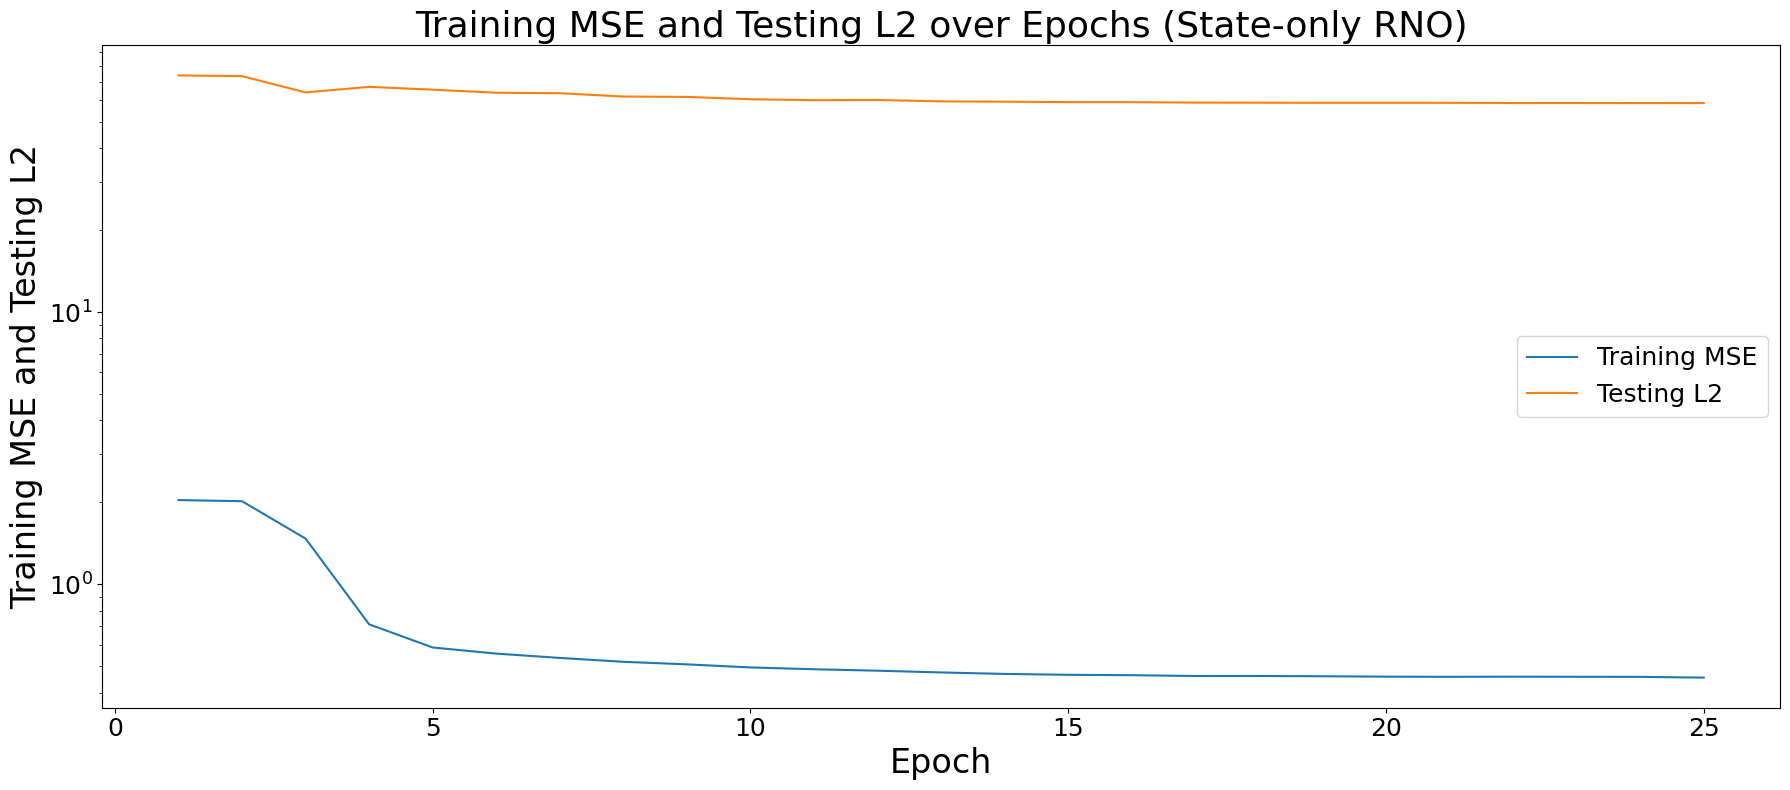

Plots saved to result_rno_state_only_32/train_and_test_loss_plots.png


In [11]:
# 9) Plot training progress (same style family as original notebooks)
df = pd.read_csv(log_file)
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 8), dpi=100)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

ax1.plot(
    df["epoch"],
    df["loss_train_mse"],
    label="Training MSE",
    color=colors[0],
    linestyle="-",
)
ax1.plot(
    df["epoch"],
    df["loss_test_l2"],
    label="Testing L2",
    color=colors[1],
    linestyle="-",
)
ax1.set_yscale("log")
ax1.set_xlabel("Epoch", fontsize=24)
ax1.set_ylabel("Training MSE and Testing L2", fontsize=24)
ax1.set_title("Training MSE and Testing L2 over Epochs (State-only RNO)", fontsize=26)
ax1.legend(loc="best", fontsize=18)
ax1.tick_params(axis="both", which="major", labelsize=18)

plt.tight_layout()
plot_path = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(plot_path, dpi=100)
plt.show()
plt.close(fig)
print(f"Plots saved to {plot_path}")


In [12]:
# 10) Save model checkpoint
model_path = os.path.join(result_dir, "rno_state_only_last.pt")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_kwargs": {
            "n_modes": (modes1, modes2),
            "hidden_channels": width,
            "in_channels": 1,
            "out_channels": 1,
            "n_layers": n_layers,
            "domain_padding": domain_padding,
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "seed": seed,
        "epochs": epochs,
        "config": {
            "modes1": modes1,
            "modes2": modes2,
            "width": width,
            "n_layers": n_layers,
            "domain_padding": domain_padding,
            "in_channels": 1,
            "out_channels": 1,
            "chunk_len": chunk_len,
            "n_intervals": n_intervals,
            "sub": sub,
            "train_frac": train_frac,
        },
        "train_loss_history": training_loss_history,
        "test_loss_history": test_loss_history,
    },
    model_path,
)
print(f"Saved checkpoint to {model_path}")


Saved checkpoint to result_rno_state_only_32/rno_state_only_last.pt


## 11) Three-Way Ablation (Shared Setup)
This section builds shared multi-horizon datasets/loaders and reusable train/eval functions.
All three models use the same architecture, data split, batch size, and endpoint-only evaluation windows.


In [13]:
# 11a) Shared setup for ablation fairness
import torch.nn.functional as F
from neuralop.models import RNO

# Fixed ablation controls
ablation_seed = int(seed)
baseline_epochs_ablation = 25

multi_step_fine_tuning = True
fine_tuning_num_steps = 5
fine_tune_ep = 5
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5

# Reproducibility root
random.seed(ablation_seed)
np.random.seed(ablation_seed)
torch.manual_seed(ablation_seed)

# Dedicated output dir for this study
ablation_result_dir = os.path.join(result_dir, "ablation_three_way")
os.makedirs(ablation_result_dir, exist_ok=True)

# Use same loss family as existing notebook
lploss_eval = LpLoss(size_average=False)

print("Ablation setup:")
print(f"seed={ablation_seed}")
print(f"baseline_epochs={baseline_epochs_ablation}")
print(f"fine_tuning_num_steps={fine_tuning_num_steps}, fine_tune_ep={fine_tune_ep}")
print(f"batch_size={batch_size}, chunk_len={chunk_len}, n_intervals={n_intervals}")
print(f"train split windows={x_train.shape[0]}, test split windows={x_test.shape[0]}")
print(
    f"sol_train_chunks={tuple(sol_train_chunks.shape)}, sol_test_chunks={tuple(sol_test_chunks.shape)}"
)


Ablation setup:
seed=32
baseline_epochs=25
fine_tuning_num_steps=5, fine_tune_ep=5
batch_size=75, chunk_len=16, n_intervals=5
train split windows=1520, test split windows=380
sol_train_chunks=(80, 25, 16, 100, 1), sol_test_chunks=(20, 25, 16, 100, 1)


In [14]:
# 11b) Build shared multi-horizon datasets and deterministic test loaders


def build_state_windows_horizon(sol_chunks, n_intervals_inner, horizon_inner):
    x_list, y_list = [], []
    for traj in sol_chunks:
        max_i = sol_chunks.shape[1] - n_intervals_inner - horizon_inner
        for i in range(max_i):
            x_list.append(traj[i : i + n_intervals_inner])
            y_list.append(traj[i + n_intervals_inner + horizon_inner - 1])

    if len(x_list) == 0:
        # Keep shape-consistent empty tensors
        x_empty = torch.empty(0, n_intervals_inner, chunk_len, nx, 1)
        y_empty = torch.empty(0, chunk_len, nx, 1)
        return x_empty.float(), y_empty.float()

    x = torch.stack(x_list, dim=0).float()  # (N, n_intervals, chunk_len, nx, 1)
    y = torch.stack(y_list, dim=0).float()  # (N, chunk_len, nx, 1)
    return x, y


horizons = list(range(1, fine_tuning_num_steps + 1))

multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    xh_tr, yh_tr = build_state_windows_horizon(sol_train_chunks, n_intervals, h)
    xh_te, yh_te = build_state_windows_horizon(sol_test_chunks, n_intervals, h)
    multi_step_train_data[h] = (xh_tr, yh_tr)
    multi_step_test_data[h] = (xh_te, yh_te)

# Shared deterministic evaluation loaders (identical windows for all models)
multi_step_test_eval_loaders = {}
for h in horizons:
    xh_te, yh_te = multi_step_test_data[h]
    multi_step_test_eval_loaders[h] = DataLoader(
        torch.utils.data.TensorDataset(xh_te, yh_te),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}
print("Evaluation samples per horizon:", n_eval_per_horizon)


Evaluation samples per horizon: {1: 380, 2: 360, 3: 340, 4: 320, 5: 300}


In [15]:
# 11c) Shared model/train/eval helpers
def build_model_with_seed(init_seed):
    torch.manual_seed(init_seed)
    np.random.seed(init_seed)
    random.seed(init_seed)
    return RNO(
        n_modes=(modes1, modes2),
        hidden_channels=width,
        in_channels=1,
        out_channels=1,
        n_layers=n_layers,
        domain_padding=domain_padding,
    ).to(device)


def run_one_step_baseline_training(
    model_obj, train_x, train_y, test_x, test_y, n_epochs, seed_for_loader
):
    # Deterministic train shuffle order for fairness.
    g = torch.Generator(device="cpu")
    g.manual_seed(seed_for_loader)
    train_loader_local = DataLoader(
        torch.utils.data.TensorDataset(train_x, train_y),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    test_loader_local = DataLoader(
        torch.utils.data.TensorDataset(test_x, test_y),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )
    optimizer_local = torch.optim.Adam(
        model_obj.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    scheduler_local = torch.optim.lr_scheduler.StepLR(
        optimizer_local, step_size=scheduler_step, gamma=scheduler_gamma
    )
    history = {"train_mse": [], "test_rel_l2": []}
    for ep in range(1, n_epochs + 1):
        t_start = time.time()
        model_obj.train()
        train_mse_sum = 0.0
        train_count = 0
        for xb, yb in train_loader_local:
            xb = xb.to(device).float()
            yb = yb.to(device).float()
            x_in = xb.permute(0, 1, 4, 2, 3)
            out = model_obj.predict(x_in, num_steps=1)[:, -1]
            out = out.permute(0, 2, 3, 1)
            loss = F.mse_loss(out, yb)
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
            scheduler_local.step()
            train_mse_sum += loss.item() * xb.size(0)
            train_count += xb.size(0)
        model_obj.eval()
        test_rel_sum = 0.0
        test_count = 0
        with torch.no_grad():
            for xb, yb in test_loader_local:
                xb = xb.to(device).float()
                yb = yb.to(device).float()
                x_in = xb.permute(0, 1, 4, 2, 3)
                out = model_obj.predict(x_in, num_steps=1)[:, -1]
                out = out.permute(0, 2, 3, 1)
                # lploss_eval returns sum over batch when size_average=False
                test_rel_sum += lploss_eval(out, yb).item()
                test_count += xb.size(0)
        train_mse = train_mse_sum / max(train_count, 1)
        test_l2 = test_rel_sum / max(test_count, 1)
        history["train_mse"].append(train_mse)
        history["test_rel_l2"].append(test_l2)
        runtime = time.time() - t_start
        print(
            f"Epoch {ep:03d}/{n_epochs} | train_mse={train_mse:.4e} | test_l2={test_l2:.4e} | runtime={runtime:.2f}s"
        )
    return history


def run_multistep_finetuning(model_obj, train_data_by_h, test_data_by_h, ft_seed):
    # Build deterministic train loaders per horizon.
    train_loaders = {}
    test_loaders = {}
    for h in horizons:
        xh_tr, yh_tr = train_data_by_h[h]
        xh_te, yh_te = test_data_by_h[h]
        g_h = torch.Generator(device="cpu")
        g_h.manual_seed(ft_seed)
        train_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(xh_tr, yh_tr),
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            generator=g_h,
        )
        test_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(xh_te, yh_te),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

    # KS-style mixed horizon list: one entry per batch in each horizon loader.
    multi_step_list_template = []
    for h in horizons:
        multi_step_list_template += [h for _ in range(len(train_loaders[h]))]

    optimizer_ft = torch.optim.Adam(
        model_obj.parameters(), lr=fine_tuning_lr, weight_decay=weight_decay
    )
    scheduler_ft = torch.optim.lr_scheduler.StepLR(
        optimizer_ft,
        step_size=fine_tune_scheduler_step,
        gamma=fine_tune_scheduler_gamma,
    )

    ft_logs = {
        "train_mse": {h: [] for h in horizons},
        "test_rel_l2": {h: [] for h in horizons},
    }

    print("Begin multi-step fine-tuning:")
    rng_ft = random.Random(ft_seed)

    for ep in range(1, fine_tune_ep + 1):
        t_start = time.time()

        multi_step_list = multi_step_list_template.copy()
        rng_ft.shuffle(multi_step_list)
        iters = {h: iter(train_loaders[h]) for h in horizons}

        model_obj.train()
        train_mse_sum = {h: 0.0 for h in horizons}
        train_l2_sum = {h: 0.0 for h in horizons}
        train_count = {h: 0 for h in horizons}

        for h in tqdm(multi_step_list, total=len(multi_step_list)):
            xb, yb = next(iters[h])
            xb = xb.to(device).float()
            yb = yb.to(device).float()

            x_in = xb.permute(0, 1, 4, 2, 3)
            out = model_obj.predict(x_in, num_steps=h)[:, -1]
            out = out.permute(0, 2, 3, 1)

            # Endpoint-only optimization loss stays MSE.
            loss = F.mse_loss(out, yb)

            optimizer_ft.zero_grad()
            loss.backward()
            optimizer_ft.step()
            scheduler_ft.step()

            train_mse_sum[h] += loss.item() * xb.size(0)
            # KS-style logging metric: per-horizon relative L2
            train_l2_sum[h] += lploss_eval(out, yb).item()
            train_count[h] += xb.size(0)

        model_obj.eval()
        test_rel_sum = {h: 0.0 for h in horizons}
        test_count = {h: 0 for h in horizons}
        with torch.no_grad():
            for h in horizons:
                for xb, yb in test_loaders[h]:
                    xb = xb.to(device).float()
                    yb = yb.to(device).float()
                    x_in = xb.permute(0, 1, 4, 2, 3)
                    out = model_obj.predict(x_in, num_steps=h)[:, -1]
                    out = out.permute(0, 2, 3, 1)
                    test_rel_sum[h] += lploss_eval(out, yb).item()
                    test_count[h] += xb.size(0)

        train_l2_list = []
        test_l2_list = []
        for h in horizons:
            train_mse_h = train_mse_sum[h] / max(train_count[h], 1)
            test_l2_h = test_rel_sum[h] / max(test_count[h], 1)

            ft_logs["train_mse"][h].append(train_mse_h)
            ft_logs["test_rel_l2"][h].append(test_l2_h)

            train_l2_list.append(train_l2_sum[h] / max(train_count[h], 1))
            test_l2_list.append(test_l2_h)

        runtime = time.time() - t_start
        print(
            f"Fine-tune epoch: {ep} Time: {runtime:.2f} Train L2: {train_l2_list} Test L2: {test_l2_list}"
        )

    return ft_logs


def evaluate_endpoint_metrics(model_obj, eval_loaders_by_h):
    model_obj.eval()
    results = {}
    with torch.no_grad():
        for h in horizons:
            loader = eval_loaders_by_h[h]
            mse_sum = 0.0
            rel_sum = 0.0
            n_total = 0
            for xb, yb in loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float()
                x_in = xb.permute(0, 1, 4, 2, 3)
                out = model_obj.predict(x_in, num_steps=h)[:, -1]
                out = out.permute(0, 2, 3, 1)
                # Per-window endpoint MSE
                mse_per = torch.mean((out - yb) ** 2, dim=(1, 2, 3))
                # Per-window endpoint relative L2 on flattened chunk
                diff_flat = (out - yb).reshape(out.shape[0], -1)
                y_flat = yb.reshape(yb.shape[0], -1)
                rel_per = torch.linalg.norm(diff_flat, dim=1) / (
                    torch.linalg.norm(y_flat, dim=1) + 1e-12
                )
                mse_sum += mse_per.sum().item()
                rel_sum += rel_per.sum().item()
                n_total += xb.size(0)
            results[h] = {
                "mse": mse_sum / max(n_total, 1),
                "rel_l2": rel_sum / max(n_total, 1),
                "N": int(n_total),
            }
    return results


## 12) Baseline-only (25 epochs one-step)
Model A: baseline training only, then multi-horizon endpoint evaluation.


In [16]:
# 12) Baseline-only run
model_A = build_model_with_seed(ablation_seed)
history_A = run_one_step_baseline_training(
    model_obj=model_A,
    train_x=x_train,
    train_y=y_train,
    test_x=x_test,
    test_y=y_test,
    n_epochs=baseline_epochs_ablation,
    seed_for_loader=ablation_seed,
)
results_baseline = evaluate_endpoint_metrics(model_A, multi_step_test_eval_loaders)
ckpt_A = {
    "model_state_dict": model_A.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "tag": "baseline_only",
}
torch.save(ckpt_A, os.path.join(ablation_result_dir, "baseline_only_state_dict.pt"))
print("Saved:", os.path.join(ablation_result_dir, "baseline_only_state_dict.pt"))


Epoch 001/25 | train_mse=2.9496e+00 | test_l2=1.2611e+00 | runtime=5.01s
Epoch 002/25 | train_mse=7.7558e-01 | test_l2=9.3712e-01 | runtime=4.44s
Epoch 003/25 | train_mse=6.7864e-01 | test_l2=9.3258e-01 | runtime=5.00s
Epoch 004/25 | train_mse=6.6060e-01 | test_l2=9.3836e-01 | runtime=5.04s
Epoch 005/25 | train_mse=6.4987e-01 | test_l2=9.2500e-01 | runtime=5.10s
Epoch 006/25 | train_mse=6.4114e-01 | test_l2=9.2047e-01 | runtime=5.19s
Epoch 007/25 | train_mse=6.3213e-01 | test_l2=9.2444e-01 | runtime=5.21s
Epoch 008/25 | train_mse=6.2823e-01 | test_l2=9.1634e-01 | runtime=4.51s
Epoch 009/25 | train_mse=6.2402e-01 | test_l2=9.3099e-01 | runtime=5.06s
Epoch 010/25 | train_mse=6.2229e-01 | test_l2=9.1456e-01 | runtime=5.04s
Epoch 011/25 | train_mse=6.1641e-01 | test_l2=9.1489e-01 | runtime=5.00s
Epoch 012/25 | train_mse=6.1505e-01 | test_l2=9.1373e-01 | runtime=5.10s
Epoch 013/25 | train_mse=6.1429e-01 | test_l2=9.1165e-01 | runtime=5.06s
Epoch 014/25 | train_mse=6.1264e-01 | test_l2=9.126

## 13) Fine-tune-only (KS-style, from random initialization)
Model B: no baseline training; multi-step fine-tuning only.


In [17]:
# 13) Fine-tune-only run
model_B = build_model_with_seed(ablation_seed)
logs_B = run_multistep_finetuning(
    model_obj=model_B,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=ablation_seed,
)
results_finetune_only = evaluate_endpoint_metrics(model_B, multi_step_test_eval_loaders)
ckpt_B = {
    "model_state_dict": model_B.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "tag": "finetune_only",
}
torch.save(ckpt_B, os.path.join(ablation_result_dir, "finetune_only_state_dict.pt"))
print("Saved:", os.path.join(ablation_result_dir, "finetune_only_state_dict.pt"))


Epoch 001/5 | train_mse=5.1249e+00 | test_l2=1.0849e+00 | runtime=29.65s
Epoch 002/5 | train_mse=9.1290e-01 | test_l2=1.0182e+00 | runtime=29.66s
Epoch 003/5 | train_mse=8.4582e-01 | test_l2=1.0510e+00 | runtime=29.58s
Epoch 004/5 | train_mse=9.9670e-01 | test_l2=1.0659e+00 | runtime=29.61s
Epoch 005/5 | train_mse=8.0229e-01 | test_l2=1.0267e+00 | runtime=29.66s
Saved: result_rno_state_only_32/ablation_three_way/finetune_only_state_dict.pt


## 14) Baseline → Fine-tune
Model C: 25-epoch baseline, then the same multi-step fine-tuning stage.


In [18]:
# 14) Baseline + fine-tune run
model_C = build_model_with_seed(ablation_seed)
history_C_baseline = run_one_step_baseline_training(
    model_obj=model_C,
    train_x=x_train,
    train_y=y_train,
    test_x=x_test,
    test_y=y_test,
    n_epochs=baseline_epochs_ablation,
    seed_for_loader=ablation_seed,  # same seed everywhere
)
logs_C_ft = run_multistep_finetuning(
    model_obj=model_C,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=ablation_seed,  # same seed everywhere
)
results_baseline_plus_finetune = evaluate_endpoint_metrics(
    model_C, multi_step_test_eval_loaders
)
ckpt_C = {
    "model_state_dict": model_C.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "tag": "baseline_plus_finetune",
}
torch.save(
    ckpt_C,
    os.path.join(ablation_result_dir, "baseline_plus_finetune_state_dict.pt"),
)
print(
    "Saved:", os.path.join(ablation_result_dir, "baseline_plus_finetune_state_dict.pt")
)


Epoch 001/25 | train_mse=2.9496e+00 | test_l2=1.2611e+00 | runtime=5.11s
Epoch 002/25 | train_mse=7.7558e-01 | test_l2=9.3712e-01 | runtime=5.09s
Epoch 003/25 | train_mse=6.7864e-01 | test_l2=9.3258e-01 | runtime=4.39s
Epoch 004/25 | train_mse=6.6060e-01 | test_l2=9.3836e-01 | runtime=5.01s
Epoch 005/25 | train_mse=6.4987e-01 | test_l2=9.2500e-01 | runtime=5.05s
Epoch 006/25 | train_mse=6.4114e-01 | test_l2=9.2047e-01 | runtime=5.03s
Epoch 007/25 | train_mse=6.3213e-01 | test_l2=9.2444e-01 | runtime=5.06s
Epoch 008/25 | train_mse=6.2823e-01 | test_l2=9.1634e-01 | runtime=5.00s
Epoch 009/25 | train_mse=6.2402e-01 | test_l2=9.3099e-01 | runtime=5.01s
Epoch 010/25 | train_mse=6.2229e-01 | test_l2=9.1456e-01 | runtime=4.40s
Epoch 011/25 | train_mse=6.1641e-01 | test_l2=9.1489e-01 | runtime=5.02s
Epoch 012/25 | train_mse=6.1505e-01 | test_l2=9.1373e-01 | runtime=5.02s
Epoch 013/25 | train_mse=6.1429e-01 | test_l2=9.1165e-01 | runtime=5.04s
Epoch 014/25 | train_mse=6.1264e-01 | test_l2=9.126

## 15) Final Comparison Table
Per-horizon endpoint-only comparison across all three runs.


In [19]:
# 15) Final ablation table
print(
    "Horizon | Baseline MSE | FT-only MSE | Base+FT MSE | Baseline RelL2 | FT-only RelL2 | Base+FT RelL2 | N"
)
print("-" * 128)

for h in horizons:
    rb = results_baseline[h]
    rf = results_finetune_only[h]
    rbf = results_baseline_plus_finetune[h]

    n_h = rb["N"]
    print(
        f"{h:>7} | "
        f"{rb['mse']:.4e} | {rf['mse']:.4e} | {rbf['mse']:.4e} | "
        f"{rb['rel_l2']:.4e} | {rf['rel_l2']:.4e} | {rbf['rel_l2']:.4e} | "
        f"{n_h}"
    )


Horizon | Baseline MSE | FT-only MSE | Base+FT MSE | Baseline RelL2 | FT-only RelL2 | Base+FT RelL2 | N
--------------------------------------------------------------------------------------------------------------------------------
      1 | 6.9719e-01 | 7.2523e-01 | 5.3337e-01 | 9.1027e-01 | 9.1922e-01 | 7.8181e-01 | 380
      2 | 1.2449e+00 | 8.5167e-01 | 6.6648e-01 | 1.2570e+00 | 1.0255e+00 | 9.0367e-01 | 360
      3 | 2.8405e+00 | 9.4616e-01 | 8.1717e-01 | 1.8189e+00 | 1.0637e+00 | 9.8752e-01 | 340
      4 | 6.2716e+00 | 1.0089e+00 | 9.4183e-01 | 2.6317e+00 | 1.0698e+00 | 1.0437e+00 | 320
      5 | 1.3608e+01 | 1.0820e+00 | 1.0572e+00 | 3.8945e+00 | 1.0762e+00 | 1.0884e+00 | 300


## 16) Compare Train Histories (All Three Models)

Train-loss curves are shown together. Fine-tune-only has `fine_tune_ep` epochs, while baseline and baseline->fine-tune include the 25-epoch baseline phase.


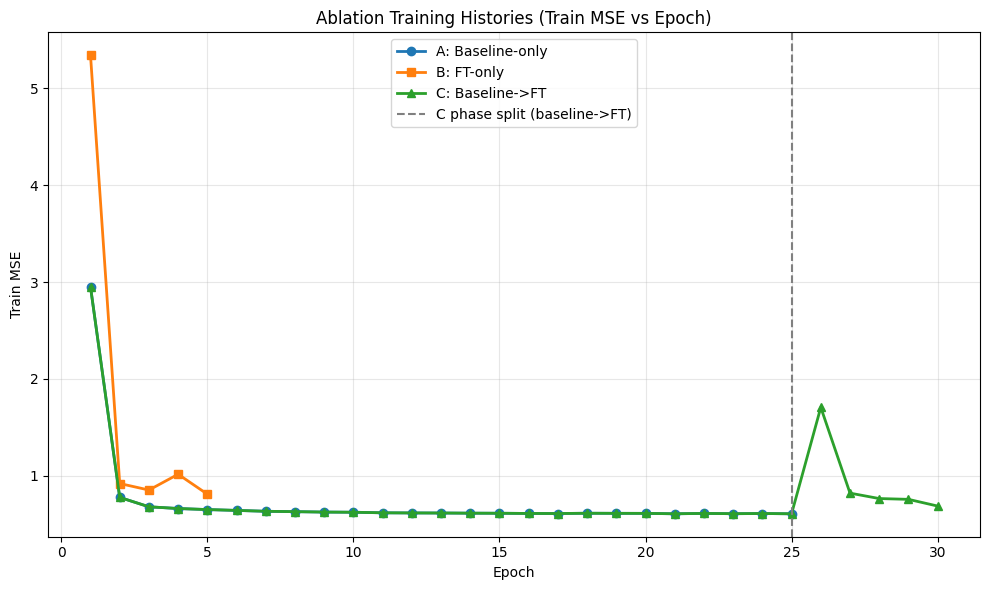

A epochs: 25, B epochs: 5, C epochs: 30
Note: B is FT-only (shorter), C includes baseline then FT phases.


In [20]:
# 16) Compare training histories for all three models (train_mse vs epoch)


def aggregate_ft_train_mse(ft_logs_obj, horizons_obj):
    # Aggregate multi-horizon FT training histories into one scalar per epoch.
    n_ep = len(ft_logs_obj["train_mse"][horizons_obj[0]])
    return [
        float(np.mean([ft_logs_obj["train_mse"][h][ep] for h in horizons_obj]))
        for ep in range(n_ep)
    ]


train_A = history_A["train_mse"]
train_B = aggregate_ft_train_mse(logs_B, horizons)
train_C_base = history_C_baseline["train_mse"]
train_C_ft = aggregate_ft_train_mse(logs_C_ft, horizons)
train_C = train_C_base + train_C_ft

epoch_A = np.arange(1, len(train_A) + 1)
epoch_B = np.arange(1, len(train_B) + 1)
epoch_C = np.arange(1, len(train_C) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epoch_A, train_A, marker="o", linewidth=2, label="A: Baseline-only")
ax.plot(epoch_B, train_B, marker="s", linewidth=2, label="B: FT-only")
ax.plot(epoch_C, train_C, marker="^", linewidth=2, label="C: Baseline->FT")
ax.axvline(
    x=baseline_epochs_ablation,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="C phase split (baseline->FT)",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train MSE")
ax.set_title("Ablation Training Histories (Train MSE vs Epoch)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"A epochs: {len(train_A)}, B epochs: {len(train_B)}, C epochs: {len(train_C)}")
print("Note: B is FT-only (shorter), C includes baseline then FT phases.")
